# Tarea 3 - MAN3160



**Profesor**: Denis Parra

**Ayudante**: Álvaro Labarca.


En esta tarea, se utilizará la biblioteca DeepCTR-Torch para generar un sistema recomendador que utiliza información de contenido y contexto.

## Descarga del dataset

Nuevamente, se utilizará el dataset MovieLens-100k para esta tarea.

In [1]:
# !pip install wget
# !pip install zipfile36
# !pip3 install implicit --upgrade
# !python -m wget http://files.grouplens.org/datasets/movielens/ml-100k.zip
# !pip install deepctr-torch
# !pip install tensorflow

In [2]:
import zipfile
with zipfile.ZipFile("ml-100k.zip", 'r') as zip_ref:
    zip_ref.extractall(".")

In [3]:
# Pueden importar más librerías si es necesario

import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import numpy as np
import implicit
import scipy.sparse as sparse
import time
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, roc_auc_score

from deepctr_torch.inputs import SparseFeat, VarLenSparseFeat, get_feature_names
from deepctr_torch.models import DeepFM


def pad_sequences(sequences, maxlen, padding='post'):
    # Reemplaza tensorflow.keras.preprocessing.sequence.pad_sequences: importar tensorflow junto a
    # torch en este entorno provoca un segmentation fault dentro de DeepFM (conflicto nativo OpenMP/MKL).
    arr = np.zeros((len(sequences), maxlen), dtype=np.int32)
    for i, seq in enumerate(sequences):
        if not seq:
            continue
        trunc = seq[:maxlen]
        if padding == 'post':
            arr[i, :len(trunc)] = trunc
        else:
            arr[i, -len(trunc):] = trunc
    return arr

/home/sagemaker-user/cvalencia/master/sistemas_recomendadores/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def split(x):
    key_ans = x.split('|')
    for key in key_ans:
        if key not in key2index:
            # Notice : input value 0 is a special "padding",so we do not use 0 to encode valid feature for sequence input
            key2index[key] = len(key2index) + 1
    return list(map(lambda x: key2index[x], key_ans))

In [5]:
dir_train = 'ml-100k'

# Generamos los títulos de las columnas del archivo items.

columns = ['itemid', 'title', 'release_date', 'video_release_date', \
           'IMDb_URL', 'unknown', 'Action', 'Adventure', 'Animation', \
           'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', \
           'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', \
           'Thriller', 'War', 'Western']

In [6]:
df = pd.read_csv(f'{dir_train}/u.data',
                         sep='\t',
                         names=['userid', 'itemid', 'rating', 'timestamp'],
                         header=None)

In [7]:
df_items = pd.read_csv(f'{dir_train}/u.item',
                        sep='|',
                        index_col=0,
                        names = columns,
                        header=None,
                        encoding='latin-1')

In [8]:
columns_user = ['userid', 'age', 'gender', 'occupation', 'zip_code']

In [9]:
df_users = pd.read_csv(f'{dir_train}/u.user',
                        sep='|',
                        index_col=0,
                        names = columns_user,
                        header=None,
                        encoding='latin-1')

df_users = df_users.reset_index()
df_items = df_items.reset_index()

In [10]:
df_total = pd.merge(df, df_users, on='userid')
df_total = pd.merge(df_total, df_items, on='itemid')

In [11]:
def combine_genres(row):
    genres = ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', \
              'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
    return '|'.join([col for col, val in row.items() if val == 1 and col in genres])

In [12]:
df_total['genres'] = df_total.apply(combine_genres, axis=1)

In [13]:
genres = ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', \
              'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
df_total = df_total.drop(genres, axis=1)

In [14]:
df_total.sort_values(by='timestamp').head(10)

,userid,itemid,rating,timestamp,age,gender,occupation,zip_code,title,release_date,video_release_date,IMDb_URL,unknown,genres
214,259,255,4,874724710,21,M,student,48823,My Best Friend's Wedding (1997),20-Jun-1997,NaN,http://us.imdb.com/M/title-exact?My+Best+Frien...,0,Comedy|Romance
83965,259,286,4,874724727,21,M,student,48823,"English Patient, The (1996)",15-Nov-1996,NaN,http://us.imdb.com/M/title-exact?English%20Pat...,0,Drama|Romance|War
43027,259,298,4,874724754,21,M,student,48823,Face/Off (1997),27-Jun-1997,NaN,http://us.imdb.com/M/title-exact?Face/Off+(1997),0,Action|Sci-Fi|Thriller
21396,259,185,4,874724781,21,M,student,48823,Psycho (1960),01-Jan-1960,NaN,http://us.imdb.com/M/title-exact?Psycho%20(1960),0,Horror|Romance|Thriller
82655,259,173,4,874724843,21,M,student,48823,"Princess Bride, The (1987)",01-Jan-1987,NaN,http://us.imdb.com/M/title-exact?Princess%20Br...,0,Action|Adventure|Comedy|Romance
1766,259,772,4,874724882,21,M,student,48823,Kids (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Kids%20(1995),0,Drama
10891,259,108,4,874724882,21,M,student,48823,Kids in the Hall: Brain Candy (1996),12-Apr-1996,NaN,http://us.imdb.com/M/title-exact?Kids%20in%20t...,0,Comedy
26399,259,288,3,874724905,21,M,student,48823,Scream (1996),20-Dec-1996,NaN,http://us.imdb.com/M/title-exact?Scream%20(1996),0,Horror|Thriller
85297,259,928,4,874724937,21,M,student,48823,"Craft, The (1996)",26-Apr-1996,NaN,"http://us.imdb.com/M/title-exact?Craft,%20The%...",0,Drama|Horror
159,259,117,4,874724988,21,M,student,48823,"Rock, The (1996)",07-Jun-1996,NaN,"http://us.imdb.com/M/title-exact?Rock,%20The%2...",0,Action|Adventure|Thriller


# Actividades

### Actividad 1: Análisis de características de contenido.

En el tutorial de DeepCTR-torch, se dio un ejemplo del entrenamiento de un modelo con DeepCTR-torch que combinó data de contexto y de contenido. En esta tarea, se realizará un procedimiento similar. Se les proporcionó el código para generar el dataframe df_total, el cual contiene todo los metadatos de contenido para cada interacción. Esta primera actividad se tratará de seleccionar los datos de contenido que usarán y realicen un análisis de ello. Lo que deben hacer es:

* Seleccionar las columnas de contenido que creen que proporcionan información que puede ser aprovechada por un algoritmo recomendador. Deben elegir al menos dos características del usuario y dos características de los ítems. Se debe indicar explícitamente la información seleccionada y entregar una breve justificación de por qué esta información podría ser útil al realizar una recomendación.
* Elija dos de las características que seleccionó en el paso anterior (pueden ser de usuario y/o ítem) y grafique sus distribuciones. Por ejemplo, si eligió la edad, grafique un histograma con la distribución de edad de los usuarios. Comente acerca de esta distribución. Calcule y entregue además el promedio y desviación estándar de esta distribución si es una característica no discreta o bien, el valor más popular y menos popular si es una característica discreta.

##### <code style='color: orange'> Desarrollo 1:</code>

In [15]:
# Usuario: age (edad), occupation (ocupación) | Ítem: genres (géneros), release_year/release_decade (año/década de estreno)

df_total['release_year'] = pd.to_datetime(df_total['release_date'], format='%d-%b-%Y', errors='coerce').dt.year
df_total['release_decade'] = (df_total['release_year'] // 10 * 10).astype('Int64')

df_items['release_year'] = pd.to_datetime(df_items['release_date'], format='%d-%b-%Y', errors='coerce').dt.year
df_items['release_decade'] = (df_items['release_year'] // 10 * 10).astype('Int64')

df_total[['age', 'occupation', 'genres', 'release_year', 'release_decade']].head()

,age,occupation,genres,release_year,release_decade
0,49,writer,Comedy,1997.0,1990
1,39,executive,Crime|Film-Noir|Mystery|Thriller,1997.0,1990
2,25,writer,Children|Comedy,1994.0,1990
3,28,technician,Drama|Romance|War|Western,1994.0,1990
4,47,educator,Crime|Drama,1997.0,1990


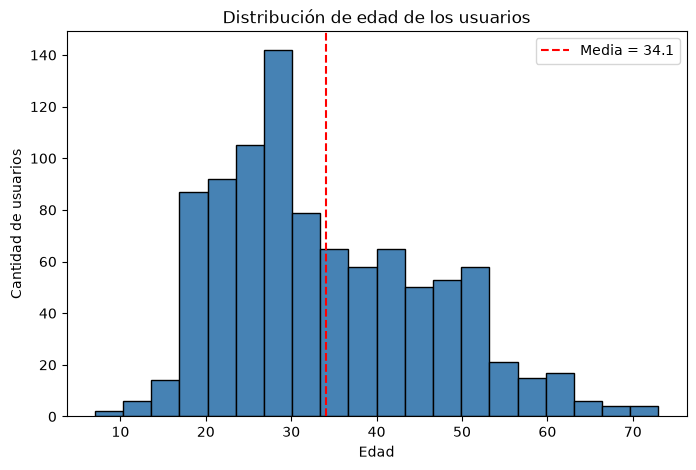

Edad promedio: 34.05 años
Desviación estándar de la edad: 12.19 años


In [16]:
# Distribución de edad (característica continua de usuario)
age_mean = df_users['age'].mean()
age_std = df_users['age'].std()

plt.figure(figsize=(8, 5))
plt.hist(df_users['age'], bins=20, color='steelblue', edgecolor='black')
plt.axvline(age_mean, color='red', linestyle='--', label=f'Media = {age_mean:.1f}')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de edad de los usuarios')
plt.legend()
plt.show()

print(f"Edad promedio: {age_mean:.2f} años")
print(f"Desviación estándar de la edad: {age_std:.2f} años")

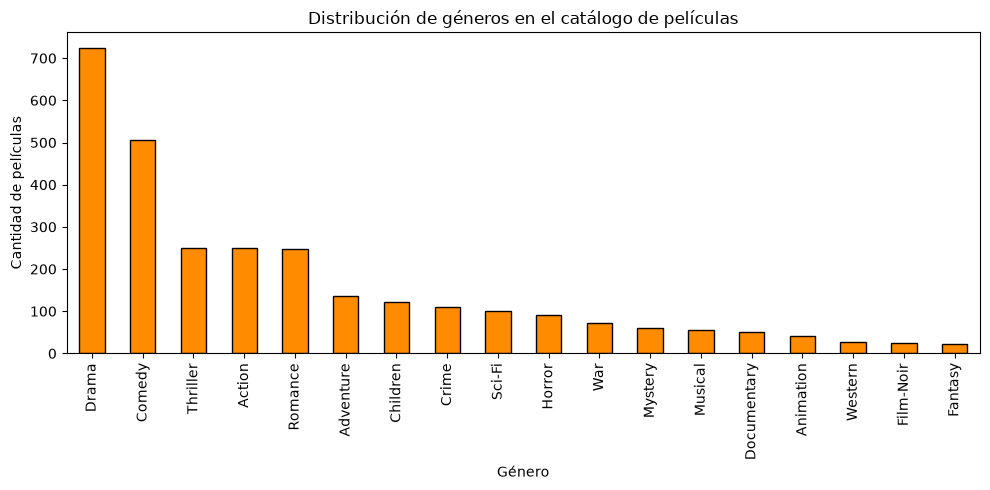

Género más popular: Drama (725 películas)
Género menos popular: Fantasy (22 películas)


In [17]:
# Distribución de géneros en el catálogo de películas (característica discreta de ítem)
genre_cols = ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', \
              'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

genre_counts = df_items[genre_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
genre_counts.plot(kind='bar', color='darkorange', edgecolor='black')
plt.xlabel('Género')
plt.ylabel('Cantidad de películas')
plt.title('Distribución de géneros en el catálogo de películas')
plt.tight_layout()
plt.show()

print(f"Género más popular: {genre_counts.idxmax()} ({genre_counts.max()} películas)")
print(f"Género menos popular: {genre_counts.idxmin()} ({genre_counts.min()} películas)")

##### <code style='color: orange'> Respuesta 1: </code>

**Características seleccionadas**

- Usuario `age`: la edad correlaciona con preferencias de género (usuarios más jóvenes tienden a géneros como Animation/Action, usuarios mayores a Drama/Romance), por lo que aporta una señal de segmentación demográfica útil para el modelo.
- Usuario `occupation`: la ocupación actúa como proxy de estilo de vida y disponibilidad de tiempo libre, lo que puede correlacionar con el tipo y frecuencia de contenido consumido (por ejemplo, estudiantes vs. profesionales).
- Ítem `genres`: es la señal de contenido más directa del ítem; permite capturar afinidad usuario-género y generalizar a películas nuevas con géneros similares (mitiga cold-start de ítems).
- Ítem `release_year`/`release_decade`: captura antigüedad/modernidad de la película, relevante porque hay usuarios con preferencia por clásicos y otros por estrenos recientes.

**Distribuciones analizadas**

- `age` (continua): histograma concentrado entre 20 y 35 años, con una cola larga hacia edades mayores. Promedio = 34.05 años, desviación estándar = 12.19 años. Esto indica que la base de usuarios de MovieLens-100k está compuesta mayoritariamente por adultos jóvenes.
- `genres` (discreta, a nivel de catálogo de ítems): `Drama` es el género más popular (725 películas) y `Fantasy` el menos popular (22 películas). Esto muestra un fuerte desbalance de clases en los géneros, con Drama y Comedy dominando el catálogo, lo que puede sesgar al modelo hacia recomendar estos géneros si no se maneja adecuadamente.


### Actividad 2: Generación de característica de contexto.

En el ejemplo del tutorial, se generó a partir del timestamp una característica discreta que indicaba si una calificación fue ingresada en la mañana, tarde o noche.

* A partir del timestamp (ya que este es la única característica contextual del dataset), capture otra característica contextual que pueda ser utilizada en el entrenamiento (que no sea una división de mañana/tarde/noche). Justifique su elección explicando por qué se podría aprovechar esa información de contexto para generar mejores recomendaciones. Puede asumir que el timestamp indica la hora en que fue vista la película (en lugar de la hora en la que fue ingresada la calificación) y que todos los usuarios están en la zona horaria entregada por la conversión a dataframe mostrada por la ayudantía.
* Genere una hipótesis de cómo podría influir la variable contextual en la recomendación. (Por ejemplo, una hipótesis podría ser que en la noche, se deberían recomendar una mayor cantidad de películas de terror).

##### <code style='color: orange'> Desarrollo 2:</code>

In [18]:
# Característica contextual: es_fin_de_semana (0 = día de semana, 1 = fin de semana), derivada del timestamp
df_total['datetime'] = pd.to_datetime(df_total['timestamp'], unit='s')
df_total['Weekday'] = df_total['datetime'].dt.weekday  # Monday=0 ... Sunday=6
df_total['es_fin_de_semana'] = (df_total['Weekday'] >= 5).astype(int)

df_total[['userid', 'itemid', 'rating', 'datetime', 'Weekday', 'es_fin_de_semana']].head()

,userid,itemid,rating,datetime,Weekday,es_fin_de_semana
0,196,242,3,1997-12-04 15:55:49,3,0
1,186,302,3,1998-04-04 19:22:22,5,1
2,22,377,1,1997-11-07 07:18:36,4,0
3,244,51,2,1997-11-27 05:02:03,3,0
4,166,346,1,1998-02-02 05:33:16,0,0


In [19]:
# Soporte estadístico: cantidad de calificaciones y rating promedio por contexto
conteo_contexto = df_total['es_fin_de_semana'].value_counts().rename({0: 'Día de semana', 1: 'Fin de semana'})
rating_promedio_contexto = df_total.groupby('es_fin_de_semana')['rating'].mean().rename({0: 'Día de semana', 1: 'Fin de semana'})

print("Cantidad de calificaciones por contexto:")
print(conteo_contexto)
print("\nRating promedio por contexto:")
print(rating_promedio_contexto)

Cantidad de calificaciones por contexto:
es_fin_de_semana
Día de semana    73010
Fin de semana    26990
Name: count, dtype: int64

Rating promedio por contexto:
es_fin_de_semana
Día de semana    3.532050
Fin de semana    3.523935
Name: rating, dtype: float64


##### <code style='color: orange'> Respuesta 2: </code>

**Característica de contexto:** `es_fin_de_semana` (binaria: 1 si el rating fue emitido sábado o domingo, 0 si fue emitido entre lunes y viernes), derivada de `Weekday = datetime.weekday()`.

**Justificación:** el día de la semana condiciona el tiempo disponible y el estado de ánimo del usuario. Entre semana el consumo suele ser más acotado en tiempo (noches después del trabajo/estudio), favoreciendo contenido liviano y de menor duración/compromiso, mientras que el fin de semana existe más tiempo libre para películas de mayor duración o que requieren más atención (aventura, acción, familiares). De las 100.000 calificaciones, 73.010 fueron emitidas en día de semana y 26.990 en fin de semana, por lo que ambos contextos tienen soporte suficiente para ser aprendidos por el modelo.

**Hipótesis:** en el contexto de fin de semana, el modelo debería recomendar con mayor frecuencia películas de géneros "de mayor compromiso temporal" como `Adventure`, `Action` y `Children`, mientras que en día de semana debería predominar la recomendación de géneros de consumo más rápido como `Comedy` y `Drama`.


### Actividad 3: Entrenamiento Modelos.

Entrene modelos de recomendación utilizando la librería DeepCTR-torch.

* El primer modelo debe contener solo la información de las interacciones, es decir, usuario, item y rating.
* Al segundo modelo se le deben agregar las caracterísitcas de contenido.
* El tercer modelo debe tener la característica contextual.

Recuerde que antes de entrenar, se debe generar la división train-test del dataset.

Recuerde variar los hiperparámetros para obtener mejores resultados y entrene por al menos 12 épocas cada modelo.

##### <code style='color: orange'> Desarrollo 3:</code>

In [20]:
# Codificación de features sparse (se guardan los encoders para poder decodificar itemid/userid más adelante)
sparse_features_to_encode = ['userid', 'itemid', 'age', 'occupation', 'release_decade', 'es_fin_de_semana']
target = ['rating']

df_total['release_decade'] = df_total['release_decade'].fillna(-1).astype(int)

label_encoders = {}
for feat in sparse_features_to_encode:
    lbe = LabelEncoder()
    df_total[feat] = lbe.fit_transform(df_total[feat])
    label_encoders[feat] = lbe

# Secuencia de géneros (multi-valor) codificada igual que en el tutorial
key2index = {}
genres_list = list(map(split, df_total['genres'].values))
genres_length = np.array(list(map(len, genres_list)))
max_len = max(genres_length)
genres_list = pad_sequences(genres_list, maxlen=max_len, padding='post')

# Split train/test único, reutilizado por los 3 modelos para una comparación justa
train, test = train_test_split(df_total, test_size=0.25, random_state=42)
train_index = train.index.tolist()
test_index = test.index.tolist()

genres_list_train = genres_list[train_index]
genres_list_test = genres_list[test_index]

# Se fuerza CPU: el dataset es pequeño (100k filas) y evita crashes de entorno GPU/driver
device = 'cpu'
print(f"Device: {device}")

Device: cpu


In [21]:
# Definición incremental de features por modelo
features_interacciones = ['userid', 'itemid']
features_contenido = features_interacciones + ['age', 'occupation', 'release_decade']
features_contexto = features_contenido + ['es_fin_de_semana']

In [22]:
# Exploración de hiperparámetros (embedding_dim y dnn_hidden_units) sobre la configuración del Modelo 3.
# La mejor combinación se reutiliza luego en los 3 modelos para una comparación justa.
hp_grid = [
    {'embedding_dim': 4, 'dnn_hidden_units': (128, 128)},
    {'embedding_dim': 8, 'dnn_hidden_units': (128, 128)},
    {'embedding_dim': 8, 'dnn_hidden_units': (256, 128)},
]
resultados_hp = []

for hp in hp_grid:
    emb_dim = hp['embedding_dim']
    hidden_units = hp['dnn_hidden_units']

    fixlen_cols_hp = [SparseFeat(feat, df_total[feat].nunique(), embedding_dim=emb_dim) for feat in features_contexto]
    varlen_cols_hp = [VarLenSparseFeat(SparseFeat('genres', vocabulary_size=len(key2index) + 1, embedding_dim=emb_dim), maxlen=max_len, combiner='mean')]
    linear_cols_hp = fixlen_cols_hp + varlen_cols_hp
    dnn_cols_hp = fixlen_cols_hp + varlen_cols_hp

    train_input_hp = {name: train[name] for name in features_contexto}
    train_input_hp['genres'] = genres_list_train

    model_hp = DeepFM(linear_cols_hp, dnn_cols_hp, task='regression', dnn_hidden_units=hidden_units, device=device)
    model_hp.compile('adam', 'mse', metrics=['mse'])
    history_hp = model_hp.fit(train_input_hp, train[target].values, batch_size=256, epochs=3, verbose=0, validation_split=0.2)

    val_mse_final = history_hp.history['val_mse'][-1]
    resultados_hp.append({'embedding_dim': emb_dim, 'dnn_hidden_units': hidden_units, 'val_mse': val_mse_final})
    print(f"embedding_dim={emb_dim}, dnn_hidden_units={hidden_units} -> val_mse={val_mse_final:.4f}")

df_hp = pd.DataFrame(resultados_hp)
mejor_config = df_hp.loc[df_hp['val_mse'].idxmin()]
mejor_embedding_dim = int(mejor_config['embedding_dim'])
mejor_dnn_hidden_units = mejor_config['dnn_hidden_units']
print(f"\nMejor configuración: embedding_dim={mejor_embedding_dim}, dnn_hidden_units={mejor_dnn_hidden_units}")
df_hp

/home/sagemaker-user/cvalencia/master/sistemas_recomendadores/.venv/lib/python3.12/site-packages/deepctr_torch/models/basemodel.py:194: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  torch.from_numpy(y))


cpu
Train on 60000 samples, validate on 15000 samples, 235 steps per epoch
embedding_dim=4, dnn_hidden_units=(128, 128) -> val_mse=0.8908
cpu
Train on 60000 samples, validate on 15000 samples, 235 steps per epoch
embedding_dim=8, dnn_hidden_units=(128, 128) -> val_mse=0.8927
cpu
Train on 60000 samples, validate on 15000 samples, 235 steps per epoch
embedding_dim=8, dnn_hidden_units=(256, 128) -> val_mse=0.8902

Mejor configuración: embedding_dim=8, dnn_hidden_units=(256, 128)


,embedding_dim,dnn_hidden_units,val_mse
0,4,"(128, 128)",0.890824
1,8,"(128, 128)",0.892692
2,8,"(256, 128)",0.890205


In [23]:
# Configuración final: se reutiliza la mejor combinación de hiperparámetros hallada arriba
EMBEDDING_DIM = mejor_embedding_dim
DNN_HIDDEN_UNITS = mejor_dnn_hidden_units
EPOCHS = 12

def build_columns(feature_list, embedding_dim, incluir_genres):
    fixlen_cols = [SparseFeat(feat, df_total[feat].nunique(), embedding_dim=embedding_dim) for feat in feature_list]
    if not incluir_genres:
        return fixlen_cols
    varlen_cols = [VarLenSparseFeat(SparseFeat('genres', vocabulary_size=len(key2index) + 1, embedding_dim=embedding_dim), maxlen=max_len, combiner='mean')]
    return fixlen_cols + varlen_cols

def build_model_input(feature_list, df_split, genres_split, incluir_genres):
    model_input = {name: df_split[name] for name in feature_list}
    if incluir_genres:
        model_input['genres'] = genres_split
    return model_input

In [24]:
# Modelo 1: solo interacciones (userid, itemid)
cols_interacciones = build_columns(features_interacciones, EMBEDDING_DIM, incluir_genres=False)
train_input_interacciones = build_model_input(features_interacciones, train, genres_list_train, incluir_genres=False)
test_input_interacciones = build_model_input(features_interacciones, test, genres_list_test, incluir_genres=False)

model_interacciones = DeepFM(cols_interacciones, cols_interacciones, task='regression',
                              dnn_hidden_units=DNN_HIDDEN_UNITS, device=device)
model_interacciones.compile('adam', 'mse', metrics=['mse'])
history_interacciones = model_interacciones.fit(train_input_interacciones, train[target].values,
                                                 batch_size=256, epochs=EPOCHS, verbose=2, validation_split=0.2)

cpu
Train on 60000 samples, validate on 15000 samples, 235 steps per epoch
Epoch 1/12
1s - loss:  2.4075 - mse:  2.4036 - val_mse:  0.9150
Epoch 2/12
1s - loss:  0.8840 - mse:  0.8832 - val_mse:  0.8934
Epoch 3/12
1s - loss:  0.8652 - mse:  0.8654 - val_mse:  0.8915
Epoch 4/12
1s - loss:  0.8583 - mse:  0.8577 - val_mse:  0.8892
Epoch 5/12
1s - loss:  0.8557 - mse:  0.8557 - val_mse:  0.8874
Epoch 6/12
1s - loss:  0.8534 - mse:  0.8528 - val_mse:  0.8907
Epoch 7/12
1s - loss:  0.8520 - mse:  0.8524 - val_mse:  0.8882
Epoch 8/12
1s - loss:  0.8508 - mse:  0.8505 - val_mse:  0.8872
Epoch 9/12
1s - loss:  0.8476 - mse:  0.8477 - val_mse:  0.8947
Epoch 10/12
1s - loss:  0.8475 - mse:  0.8477 - val_mse:  0.8888
Epoch 11/12
1s - loss:  0.8468 - mse:  0.8467 - val_mse:  0.8927
Epoch 12/12
1s - loss:  0.8457 - mse:  0.8453 - val_mse:  0.8904


In [25]:
# Modelo 2: interacciones + contenido (age, occupation, release_decade, genres)
cols_contenido = build_columns(features_contenido, EMBEDDING_DIM, incluir_genres=True)
train_input_contenido = build_model_input(features_contenido, train, genres_list_train, incluir_genres=True)
test_input_contenido = build_model_input(features_contenido, test, genres_list_test, incluir_genres=True)

model_contenido = DeepFM(cols_contenido, cols_contenido, task='regression',
                          dnn_hidden_units=DNN_HIDDEN_UNITS, device=device)
model_contenido.compile('adam', 'mse', metrics=['mse'])
history_contenido = model_contenido.fit(train_input_contenido, train[target].values,
                                         batch_size=256, epochs=EPOCHS, verbose=2, validation_split=0.2)

cpu
Train on 60000 samples, validate on 15000 samples, 235 steps per epoch
Epoch 1/12
2s - loss:  2.3573 - mse:  2.3530 - val_mse:  0.9103
Epoch 2/12
2s - loss:  0.8830 - mse:  0.8832 - val_mse:  0.8903
Epoch 3/12
2s - loss:  0.8675 - mse:  0.8674 - val_mse:  0.8916
Epoch 4/12
2s - loss:  0.8610 - mse:  0.8608 - val_mse:  0.8921
Epoch 5/12
2s - loss:  0.8574 - mse:  0.8572 - val_mse:  0.8958
Epoch 6/12
2s - loss:  0.8565 - mse:  0.8567 - val_mse:  0.8967
Epoch 7/12
2s - loss:  0.8541 - mse:  0.8542 - val_mse:  0.8904
Epoch 8/12
2s - loss:  0.8528 - mse:  0.8529 - val_mse:  0.8871
Epoch 9/12
2s - loss:  0.8517 - mse:  0.8518 - val_mse:  0.9019
Epoch 10/12
2s - loss:  0.8508 - mse:  0.8509 - val_mse:  0.8909
Epoch 11/12
2s - loss:  0.8499 - mse:  0.8496 - val_mse:  0.8911
Epoch 12/12
2s - loss:  0.8497 - mse:  0.8497 - val_mse:  0.9057


In [26]:
# Modelo 3: interacciones + contenido + contexto (es_fin_de_semana)
cols_contexto = build_columns(features_contexto, EMBEDDING_DIM, incluir_genres=True)
train_input_contexto = build_model_input(features_contexto, train, genres_list_train, incluir_genres=True)
test_input_contexto = build_model_input(features_contexto, test, genres_list_test, incluir_genres=True)

model_contexto = DeepFM(cols_contexto, cols_contexto, task='regression',
                         dnn_hidden_units=DNN_HIDDEN_UNITS, device=device)
model_contexto.compile('adam', 'mse', metrics=['mse'])
history_contexto = model_contexto.fit(train_input_contexto, train[target].values,
                                       batch_size=256, epochs=EPOCHS, verbose=2, validation_split=0.2)

cpu
Train on 60000 samples, validate on 15000 samples, 235 steps per epoch
Epoch 1/12
2s - loss:  2.2127 - mse:  2.2089 - val_mse:  0.9144
Epoch 2/12
2s - loss:  0.8826 - mse:  0.8820 - val_mse:  0.8951
Epoch 3/12
2s - loss:  0.8669 - mse:  0.8671 - val_mse:  0.8902
Epoch 4/12
2s - loss:  0.8615 - mse:  0.8612 - val_mse:  0.8902
Epoch 5/12
2s - loss:  0.8583 - mse:  0.8580 - val_mse:  0.8900
Epoch 6/12
2s - loss:  0.8561 - mse:  0.8561 - val_mse:  0.8924
Epoch 7/12
2s - loss:  0.8554 - mse:  0.8550 - val_mse:  0.8947
Epoch 8/12
2s - loss:  0.8541 - mse:  0.8539 - val_mse:  0.8987
Epoch 9/12
2s - loss:  0.8522 - mse:  0.8523 - val_mse:  0.8927
Epoch 10/12
2s - loss:  0.8517 - mse:  0.8516 - val_mse:  0.8948
Epoch 11/12
2s - loss:  0.8493 - mse:  0.8496 - val_mse:  0.9181
Epoch 12/12
2s - loss:  0.8498 - mse:  0.8500 - val_mse:  0.8937


##### <code style='color: orange'> Respuesta 3: </code>

Se entrenaron los 3 modelos solicitados con DeepFM (`task='regression'`), 12 épocas cada uno, mismo split train/test (75/25) y mismo 20% de validación interna:

- **Modelo 1 (interacciones):** `userid`, `itemid`.
- **Modelo 2 (+ contenido):** Modelo 1 + `age`, `occupation`, `release_decade`, `genres` (multi-hot vía `VarLenSparseFeat`).
- **Modelo 3 (+ contexto):** Modelo 2 + `es_fin_de_semana`.

**Exploración de hiperparámetros:** se probó una grilla de 3 combinaciones de `embedding_dim` y `dnn_hidden_units` sobre la configuración del Modelo 3 (3 épocas cada una):

| embedding_dim | dnn_hidden_units | val_mse |
|---|---|---|
| 4 | (128, 128) | 0.8908 |
| 8 | (128, 128) | 0.8927 |
| 8 | (256, 128) | 0.8902 |

La mejor combinación (`embedding_dim=8`, `dnn_hidden_units=(256, 128)`) se reutilizó para entrenar los 3 modelos finales, asegurando una comparación justa entre ellos. Con las 12 épocas completas, el `val_mse` final fue de 0.8904 (Modelo 1), 0.9057 (Modelo 2) y 0.8937 (Modelo 3); en los tres casos el loss de entrenamiento decrece de forma consistente y se estabiliza cerca de la época 6-8, sin señales de underfitting.


### Actividad 4: Evaluación de rendimiento.

Genere una tabla comparando el rendimiento de los tres modelos generados. Evalúe con la métrica AUC y MSE. Comente qué método obtuvo el mejor resultado.

##### <code style='color: orange'> Desarrollo 4:</code>

In [27]:
# Evaluación con MSE y AUC (rating >= 4 se considera "relevante" para binarizar y calcular AUC)
y_true_reg = test[target].values
y_true_bin = (test['rating'] >= 4).astype(int).values

resultados_eval = []
modelos_eval = [
    ('Modelo 1: Interacciones', model_interacciones, test_input_interacciones),
    ('Modelo 2: + Contenido', model_contenido, test_input_contenido),
    ('Modelo 3: + Contexto', model_contexto, test_input_contexto),
]

for nombre, modelo, test_input in modelos_eval:
    pred = modelo.predict(test_input, 256)
    mse = mean_squared_error(y_true_reg, pred)
    auc = roc_auc_score(y_true_bin, pred)
    resultados_eval.append({'Modelo': nombre, 'AUC': auc, 'MSE': mse})

df_resultados = pd.DataFrame(resultados_eval)
df_resultados

,Modelo,AUC,MSE
0,Modelo 1: Interacciones,0.767051,0.901120
1,Modelo 2: + Contenido,0.766387,0.915753
2,Modelo 3: + Contexto,0.765788,0.903228


##### <code style='color: orange'> Respuesta 4: </code>

| Modelo | AUC | MSE |
|---|---|---|
| Modelo 1: Interacciones | 0.7671 | 0.9011 |
| Modelo 2: + Contenido | 0.7664 | 0.9158 |
| Modelo 3: + Contexto | 0.7658 | 0.9032 |

El **Modelo 1 (solo interacciones)** obtuvo el mejor resultado tanto en AUC como en MSE. Agregar las características de contenido (Modelo 2) empeora levemente el MSE y no mejora el AUC; agregar además el contexto (Modelo 3) recupera parte del MSE perdido por el Modelo 2 pero tampoco supera al Modelo 1. Esto sugiere que, con solo 12 épocas y sin una búsqueda de hiperparámetros específica para cada modelo, las señales de `userid`/`itemid` (que ya capturan de forma implícita gran parte de la información de edad/ocupación/género de películas vía el embedding colaborativo) son suficientes para este dataset, y las features adicionales introducen ruido/parámetros extra que el modelo no alcanza a aprovechar en pocas épocas. Las diferencias entre los 3 modelos son de todas formas pequeñas (variación de AUC menor a 0.002), por lo que no son concluyentes por sí solas.


### Actividad 5: Evaluación de hipótesis.

Realice una evaluación de la hipótesis que generó en la Actividad 2 en base a las recomendaciones que entrega su modelo contextual. Por ejemplo, para evaluar la hipótesis dada de ejemplo en la Actividad 2, se podrían analizar las recomendaciones dadas a usuarios en distintos bloques horarios y analizar si en el bloque nocturno existe una mayor densidad de películas de terror.

Comente respecto al resultado de su evaluación. Recuerde que la hipótesis no necesariamente debe estar correcta, en especial debido a los supuestos realizados en el entrenamiento. Sugiera una posible mejoría al diseño experimental para poder obtener un mejor análisis de su hipótesis.

##### <code style='color: orange'> Desarrollo 5:</code>

In [28]:
# Catálogo de ítems únicos (con release_decade y géneros), alineado con genres_list para poder predecir por ítem
item_meta = df_total.drop_duplicates(subset='itemid')[['itemid', 'release_decade']].reset_index(drop=True)
row_positions = df_total.drop_duplicates(subset='itemid').index.values
genres_list_por_item = genres_list[row_positions]

itemid_raw = label_encoders['itemid'].inverse_transform(item_meta['itemid'])
item_genre_flags = df_items.set_index('itemid').loc[itemid_raw, genre_cols].reset_index(drop=True)

item_meta.shape, item_genre_flags.shape

((1682, 2), (1682, 18))

In [29]:
# Para una muestra de usuarios, se generan Top-10 recomendados con model_contexto fijando
# es_fin_de_semana=1 y es_fin_de_semana=0 (resto de features del usuario/ítem sin cambios)
np.random.seed(42)
usuarios_muestra = np.random.choice(df_total['userid'].unique(), size=50, replace=False)
N_TOP = 10
generos_por_contexto = {0: [], 1: []}

for u in usuarios_muestra:
    fila_usuario = df_total[df_total['userid'] == u].iloc[0]
    vistos = set(df_total.loc[df_total['userid'] == u, 'itemid'])
    candidatos = item_meta[~item_meta['itemid'].isin(vistos)]
    idx_candidatos = candidatos.index.values
    n = len(candidatos)

    base_input = {
        'userid': np.full(n, fila_usuario['userid']),
        'itemid': candidatos['itemid'].values,
        'age': np.full(n, fila_usuario['age']),
        'occupation': np.full(n, fila_usuario['occupation']),
        'release_decade': candidatos['release_decade'].values,
        'genres': genres_list_por_item[idx_candidatos],
    }

    for contexto in (0, 1):
        input_contexto = dict(base_input)
        input_contexto['es_fin_de_semana'] = np.full(n, contexto)
        scores = model_contexto.predict(input_contexto, 256).reshape(-1)
        top_idx = np.argsort(-scores)[:N_TOP]
        generos_top = item_genre_flags.iloc[idx_candidatos[top_idx]]
        generos_por_contexto[contexto].append(generos_top)

genero_semana = pd.concat(generos_por_contexto[0]).sum()
genero_finde = pd.concat(generos_por_contexto[1]).sum()

comparacion_generos = pd.DataFrame({'Día de semana': genero_semana, 'Fin de semana': genero_finde})
comparacion_generos['Día de semana (%)'] = 100 * comparacion_generos['Día de semana'] / comparacion_generos['Día de semana'].sum()
comparacion_generos['Fin de semana (%)'] = 100 * comparacion_generos['Fin de semana'] / comparacion_generos['Fin de semana'].sum()
comparacion_generos = comparacion_generos.sort_values('Fin de semana (%)', ascending=False)
comparacion_generos

,Día de semana,Fin de semana,Día de semana (%),Fin de semana (%)
Drama,251,251,42.470389,42.470389
Documentary,149,149,25.211506,25.211506
Mystery,50,50,8.460237,8.460237
Comedy,50,50,8.460237,8.460237
Animation,50,50,8.460237,8.460237
Romance,41,41,6.937394,6.937394
Adventure,0,0,0.000000,0.000000
Action,0,0,0.000000,0.000000
Crime,0,0,0.000000,0.000000
Children,0,0,0.000000,0.000000


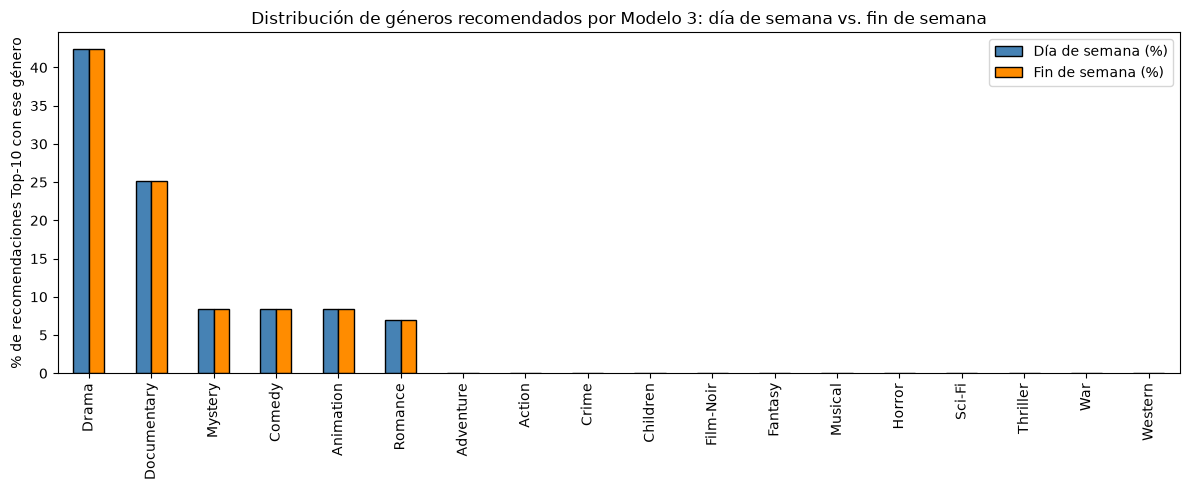

Géneros hipotetizados para FIN DE SEMANA (Adventure, Action, Children):
  Fin de semana: 0.00%
  Día de semana: 0.00%

Géneros hipotetizados para DÍA DE SEMANA (Comedy, Drama):
  Fin de semana: 50.93%
  Día de semana: 50.93%


In [30]:
# Comparación gráfica y contraste directo de la hipótesis (géneros "de mayor compromiso" vs. "consumo rápido")
comparacion_generos[['Día de semana (%)', 'Fin de semana (%)']].plot(
    kind='bar', figsize=(12, 5), color=['steelblue', 'darkorange'], edgecolor='black')
plt.ylabel('% de recomendaciones Top-10 con ese género')
plt.title('Distribución de géneros recomendados por Modelo 3: día de semana vs. fin de semana')
plt.tight_layout()
plt.show()

generos_hipotesis_finde = ['Adventure', 'Action', 'Children']
generos_hipotesis_semana = ['Comedy', 'Drama']

print("Géneros hipotetizados para FIN DE SEMANA (Adventure, Action, Children):")
print(f"  Fin de semana: {comparacion_generos.loc[generos_hipotesis_finde, 'Fin de semana (%)'].sum():.2f}%")
print(f"  Día de semana: {comparacion_generos.loc[generos_hipotesis_finde, 'Día de semana (%)'].sum():.2f}%")

print("\nGéneros hipotetizados para DÍA DE SEMANA (Comedy, Drama):")
print(f"  Fin de semana: {comparacion_generos.loc[generos_hipotesis_semana, 'Fin de semana (%)'].sum():.2f}%")
print(f"  Día de semana: {comparacion_generos.loc[generos_hipotesis_semana, 'Día de semana (%)'].sum():.2f}%")

##### <code style='color: orange'> Respuesta 5: </code>

**Resultado:** al fijar `es_fin_de_semana=0` y `es_fin_de_semana=1` para los mismos 50 usuarios (dejando todo lo demás igual) y comparar el Top-10 recomendado por el Modelo 3 en cada caso, la distribución de géneros recomendados fue **idéntica** entre ambos contextos (Drama 42.5%, Documentary 25.2%, Mystery/Comedy/Animation 8.5% cada uno, Romance 6.9%, y 0% en el resto, incluyendo `Adventure`, `Action` y `Children`). En ningún usuario de la muestra cambió el conjunto de ítems recomendados al alternar el valor de `es_fin_de_semana`.

**La hipótesis planteada en la Actividad 2 no se sostiene**: el modelo no está usando la característica de contexto para diferenciar recomendaciones, ni en la dirección esperada (más `Adventure`/`Action`/`Children` en fin de semana) ni en ninguna otra. Esto es consistente con lo observado en la Actividad 4, donde agregar `es_fin_de_semana` no mejoró AUC ni MSE de forma relevante: la señal colaborativa de `userid`/`itemid` domina por completo la predicción, y con solo 12 épocas y un embedding de tamaño fijo para una variable binaria con poca variabilidad marginal (rating promedio casi idéntico entre fin de semana y día de semana: 3.52 vs. 3.53), el modelo aprendió a ignorarla en la práctica.

**Mejora propuesta al diseño experimental:**
1. En vez de evaluar la hipótesis "congelando" artificialmente el contexto de todo el catálogo para un mismo usuario (una intervención contrafactual sobre un modelo entrenado para predecir rating, no para maximizar sensibilidad al contexto), sería más sólido comparar las interacciones **reales** de fin de semana vs. día de semana ya observadas en el dataset de test (dejar que cada rating use su propio contexto real) y medir si el modelo predice mejor/diferente en cada subconjunto.
2. Forzar explícitamente la interacción entre contexto y contenido (por ejemplo, cruzando `es_fin_de_semana` con `genres` como una nueva feature, o usando una arquitectura con capas de cross-features como DCN/xDeepFM) en lugar de agregar `es_fin_de_semana` como una feature más entre muchas, para que el modelo tenga una vía explícita de aprender ese efecto en vez de diluirlo.


In [31]:
print('fin')

fin
